In [8]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
# import torch
# import torch.nn.functional as F
import matplotlib.patches as patches

import sys
import os
import pickle

sys.path.insert(0, os.path.abspath('../..'))
import repo_paths  # noqa: F401

%load_ext autoreload
%autoreload 2

from loading_runs import load_results_from_pickle, load_pickle
from mnist_tools import show_patch_explainer

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


INVASE

- /255
- Lambda:              0.4
- Prediction accuracy: 0.9942734430923408
- % Significant feats: 0.08163265306122448

Hide\&Seek

- standard scaling
- Lambda: 0.05
- Prediction accuracy: 0.9935576234788833
- % Significant feats: 0.18820668926124495

LIME

- 255
- Prediction accuracy: 0.9971367215461704
- % Significant feats: 0.09948979591836735

REAL-x

- standard scaling
- Lambda:              0.05   
- Prediction accuracy: 0.9906943450250537
- % Significant feats: 0.09447814558894424

SHAP

- 255, but both same
- Prediction accuracy: 0.9935576234788833

In [9]:
paths = [
    os.path.expanduser('~/Data/ICML_experiments/mnist/invase/results_2026-02-04_12-32-00_val_0.4_3_invase_mnist_run.pkl'),
        os.path.expanduser('~/Data/ICML_experiments/mnist/hide_and_seek/not_255_but_standardized/results_2026-03-13_16-20-06_val_0.05_3_hide_and_seek_mnist_run.pkl'),
        os.path.expanduser('~/Data/ICML_experiments/mnist/lime/results_2026-04-23_11-39-34_val_0.3_78_lime_mnist_run.pkl'),
    os.path.expanduser('~/Data/ICML_experiments/mnist/realx/standardized/results_2026-04-23_13-25-07_val_0.05_3_realx_mnist_run.pkl'),
    os.path.expanduser('~/Data/ICML_experiments/mnist/shap_xgboost/results_2026-03-13_13-46-53_val_0.3_235_shap_xgboost_mnist_run.pkl')
        ]
#note - 'val' means test. They were swapped, but consistently, all good

invase 
 0.4 10000 1000 0.9942734430923408 0.08163265306122448

    Lambda:              0.4
    Epochs:              10000
    Batch size:          1000
    
    Prediction accuracy: 0.9942734430923408
    % Significant feats: 0.08163265306122448
    
[189, 486, 1127, 220, 825, 264]


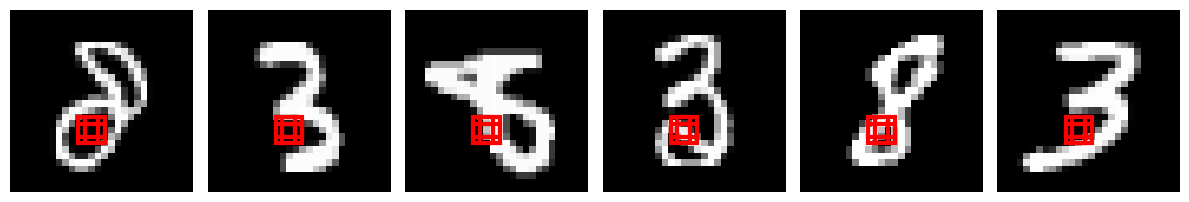


hide_and_seek 
 0.05 500 None 0.9935576234788833 0.18820668926124495

    Lambda:              0.05
    Epochs:              500
    Batch size:          None
    
    Prediction accuracy: 0.9935576234788833
    % Significant feats: 0.18820668926124495
    
[189, 486, 1127, 220, 825, 264]


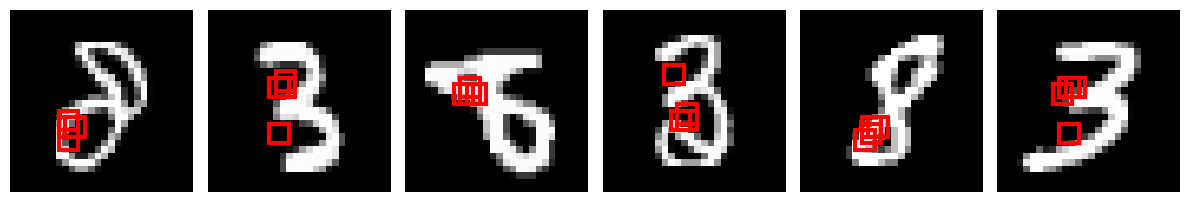


lime 
 0.3 100 None 0.9971367215461704 0.09948979591836735

    Lambda:              0.3
    Epochs:              100
    Batch size:          None
    
    Prediction accuracy: 0.9971367215461704
    % Significant feats: 0.09948979591836735
    
[189, 486, 1127, 220, 825, 264]


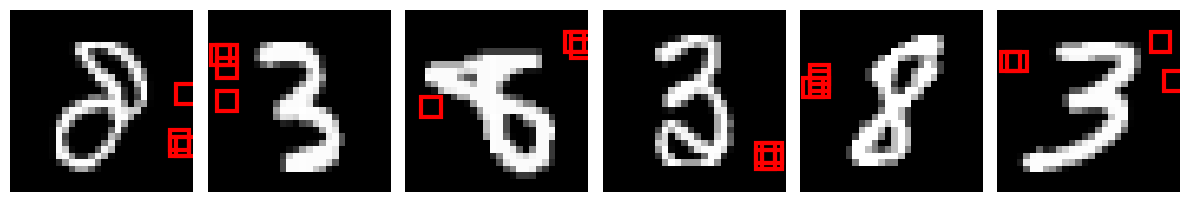


realx 
 0.05 500 1000 0.9906943450250537 0.09447814558894424

    Lambda:              0.05
    Epochs:              500
    Batch size:          1000
    
    Prediction accuracy: 0.9906943450250537
    % Significant feats: 0.09447814558894424
    
[189, 486, 1127, 220, 825, 264]


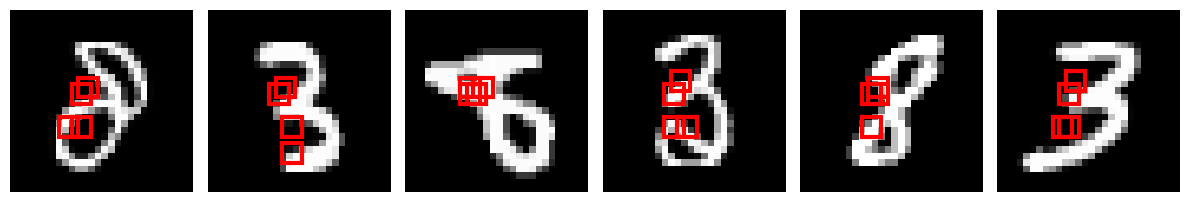


shap_xgboost 
 0.3 500 None 0.9935576234788833 0.004290352504638219

    Lambda:              0.3
    Epochs:              500
    Batch size:          None
    
    Prediction accuracy: 0.9935576234788833
    % Significant feats: 0.004290352504638219
    
[189, 486, 1127, 220, 825, 264]


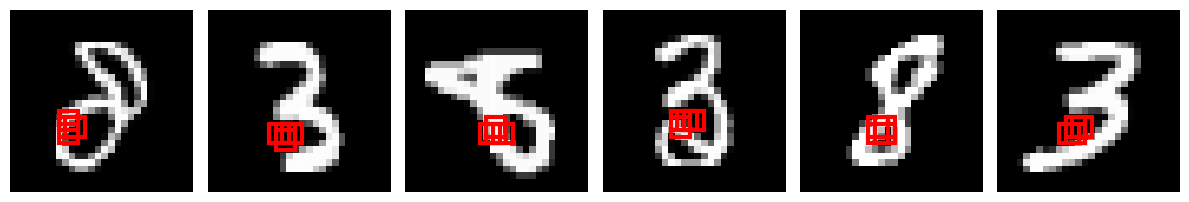

In [37]:
for path in paths:
    mnist_results = load_pickle(path)
    model = mnist_results['results']['model_type']
    print(model,'\n',
          mnist_results['results']['lmbda'],
          mnist_results['results']['epochs'],
          mnist_results['results']['batch_size'],
          mnist_results['acc'], 
          mnist_results['pct_significant']
         )

    print(f"""
    Lambda:              {mnist_results['results']['lmbda']}
    Epochs:              {mnist_results['results']['epochs']}
    Batch size:          {mnist_results['results']['batch_size']}
    
    Prediction accuracy: {mnist_results['acc']}
    % Significant feats: {mnist_results['pct_significant']}
    """)

    data_X=mnist_results['data_X']
    data_y=mnist_results['data_y']
    if model == 'lime':
        mask=np.abs(mnist_results['results']['lime_explanations'].fillna(0).values)
    else:
        mask=mnist_results['mask']
    y_preds=mnist_results['results']['y_test_pred']

    indices = show_patch_explainer(data_X=data_X, 
                        data_y=data_y,
                                   y_preds=y_preds,
                        mask=mask,
                            n_images=6,
                            num_top_patches=4,
                            patch_size=3,
                            cols=6,
                            return_indices=True,
                                   indices=[189, 486, 1127, 220, 825, 264],
                                   save_path=os.path.join(os.path.abspath('..'), 'figures', f'mnist_{model}.pdf')
                            )
    print()